# Hospital Readmission Penalties — Who's Losing Money and Why?

Medicare penalizes hospitals up to 3% of their total Medicare payments if too many patients get readmitted within 30 days. The program is called HRRP (Hospital Readmissions Reduction Program) and it tracks 6 conditions: heart attack, heart failure, pneumonia, COPD, hip/knee replacement, and CABG surgery.

The key metric is the **Excess Readmission Ratio (ERR)**:
- ERR = 1.0 means the hospital's readmission rate matches what's expected
- ERR > 1.0 means MORE readmissions than expected (bad — this triggers penalties)
- ERR < 1.0 means fewer readmissions than expected (good)

**What I'm trying to answer:**
- Which conditions drive the most excess readmissions?
- Do for-profit hospitals perform worse than non-profits?
- Is there a real correlation between star ratings and readmissions?
- Which hospitals are the "worst offenders" failing on multiple conditions?
- Do bigger hospitals do better or worse?

If a hospital administrator looked at this analysis, they'd know which conditions to prioritize, whether their ownership type puts them at risk, and how they compare to national benchmarks.

**Data:** 3 datasets from [data.cms.gov](https://data.cms.gov) (real government data, not kaggle)
- HRRP dataset — excess readmission ratios per hospital per condition
- Unplanned Hospital Visits — actual readmission rates + comparison to national avg
- Hospital General Info — ownership, star ratings, location

In [43]:
#!pip install scipy


In [5]:
import pandas as pd
import sqlite3
import os
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

conn = sqlite3.connect('hospital_readmissions.db')
cursor = conn.cursor()

---
## 1. Loading Raw Data
reading everything as strings first — learned this the hard way. CMS puts "Not Available" in columns that should be numbers and pandas freaks out if you dont force dtype=str

In [6]:
os.listdir('data/raw/')

['FY_2026_Hospital_Readmissions_Reduction_Program_Hospital.csv',
 '.DS_Store',
 'Unplanned_Hospital_Visits-Hospital.csv',
 'Hospital_General_Information.csv']

In [7]:
df1 = pd.read_csv('data/raw/Hospital_General_Information.csv', dtype=str)
df1.to_sql('raw_hospital_info', conn, if_exists='replace', index=False)

df2 = pd.read_csv('data/raw/FY_2026_Hospital_Readmissions_Reduction_Program_Hospital.csv', dtype=str)
df2.to_sql('raw_hrrp', conn, if_exists='replace', index=False)

df3 = pd.read_csv('data/raw/Unplanned_Hospital_Visits-Hospital.csv', dtype=str)
df3.to_sql('raw_unplanned_visits', conn, if_exists='replace', index=False)

print(f'hospital info: {len(df1)} rows')
print(f'hrrp: {len(df2)} rows')
print(f'unplanned visits: {len(df3)} rows')

hospital info: 5426 rows
hrrp: 18330 rows
unplanned visits: 67046 rows


---
## 2. Exploring the Raw Data
gotta understand what we're dealing with before cleaning anything

In [8]:
# quick look at each table
pd.read_sql("SELECT * FROM raw_hospital_info LIMIT 3", conn)

,Facility ID,Facility Name,Address,City/Town,State,ZIP Code,County/Parish,Telephone Number,Hospital Type,Hospital Ownership,...,Count of READM Measures Better,Count of READM Measures No Different,Count of READM Measures Worse,READM Group Footnote,Pt Exp Group Measure Count,Count of Facility Pt Exp Measures,Pt Exp Group Footnote,TE Group Measure Count,Count of Facility TE Measures,TE Group Footnote
0,010001,SOUTHEAST HEALTH MEDICAL CENTER,1108 ROSS CLARK CIRCLE,DOTHAN,AL,36301,HOUSTON,(334) 793-8701,Acute Care Hospitals,Government - Hospital District or Authority,...,0,11,0,None,8,8,None,12,11,None
1,010005,MARSHALL MEDICAL CENTERS,2505 U S HIGHWAY 431 NORTH,BOAZ,AL,35957,MARSHALL,(256) 593-8310,Acute Care Hospitals,Government - Hospital District or Authority,...,0,8,1,None,8,8,None,12,12,None
2,010006,NORTH ALABAMA MEDICAL CENTER,1701 VETERANS DRIVE,FLORENCE,AL,35630,LAUDERDALE,(256) 768-8400,Acute Care Hospitals,Proprietary,...,0,8,1,None,8,8,None,12,10,None


In [9]:
pd.read_sql("SELECT * FROM raw_hrrp LIMIT 3", conn)

,Facility Name,Facility ID,State,Measure Name,Number of Discharges,Footnote,Excess Readmission Ratio,Predicted Readmission Rate,Expected Readmission Rate,Number of Readmissions,Start Date,End Date
0,SOUTHEAST HEALTH MEDICAL CENTER,010001,AL,READM-30-HIP-KNEE-HRRP,NaN,None,0.9875,4.5734,4.6311,Too Few to Report,07/01/2021,06/30/2024
1,SOUTHEAST HEALTH MEDICAL CENTER,010001,AL,READM-30-CABG-HRRP,137,None,0.9531,10.3960,10.9078,13,07/01/2021,06/30/2024
2,SOUTHEAST HEALTH MEDICAL CENTER,010001,AL,READM-30-AMI-HRRP,273,None,0.9370,13.2998,14.1948,33,07/01/2021,06/30/2024


In [10]:
pd.read_sql("SELECT * FROM raw_unplanned_visits LIMIT 3", conn)

,Facility ID,Facility Name,Address,City/Town,State,ZIP Code,County/Parish,Telephone Number,Measure ID,Measure Name,Compared to National,Denominator,Score,Lower Estimate,Higher Estimate,Number of Patients,Number of Patients Returned,Footnote,Start Date,End Date
0,010001,SOUTHEAST HEALTH MEDICAL CENTER,1108 ROSS CLARK CIRCLE,DOTHAN,AL,36301,HOUSTON,(334) 793-8701,EDAC_30_AMI,Hospital return days for heart attack patients,Fewer Days Than Average per 100 Discharges,273,-15.6,-25.9,-4.2,264,68,None,07/01/2021,06/30/2024
1,010001,SOUTHEAST HEALTH MEDICAL CENTER,1108 ROSS CLARK CIRCLE,DOTHAN,AL,36301,HOUSTON,(334) 793-8701,EDAC_30_HF,Hospital return days for heart failure patients,Average Days per 100 Discharges,652,-1.1,-10,7.9,541,186,None,07/01/2021,06/30/2024
2,010001,SOUTHEAST HEALTH MEDICAL CENTER,1108 ROSS CLARK CIRCLE,DOTHAN,AL,36301,HOUSTON,(334) 793-8701,EDAC_30_PN,Hospital return days for pneumonia patients,More Days Than Average per 100 Discharges,507,17.4,8.2,27.5,471,114,None,07/01/2021,06/30/2024


In [11]:
# this file mixes a bunch of different measure types together
# need to see whats in here
pd.read_sql("""
    SELECT [Measure ID], COUNT(*) as cnt 
    FROM raw_unplanned_visits 
    GROUP BY [Measure ID]
""", conn)

,Measure ID,cnt
0,EDAC_30_AMI,4789
1,EDAC_30_HF,4789
2,EDAC_30_PN,4789
3,Hybrid_HWR,4789
4,OP_32,4789
5,OP_35_ADM,4789
6,OP_35_ED,4789
7,OP_36,4789
8,READM_30_AMI,4789
9,READM_30_CABG,4789


14 different measure types in one file. only the 6 READM_30 ones are relevant for this analysis. the EDAC ones measure excess days in acute care (different metric) and the OP ones are outpatient measures. gotta filter later.

In [12]:
# checking column names for the SQL queries later
print("HRRP columns:")
display(pd.read_sql("PRAGMA table_info(raw_hrrp)", conn))
print("\nUnplanned visits columns:")
display(pd.read_sql("PRAGMA table_info(raw_unplanned_visits)", conn))

HRRP columns:


,cid,name,type,notnull,dflt_value,pk
0,0,Facility Name,TEXT,0,None,0
1,1,Facility ID,TEXT,0,None,0
2,2,State,TEXT,0,None,0
3,3,Measure Name,TEXT,0,None,0
4,4,Number of Discharges,TEXT,0,None,0
5,5,Footnote,TEXT,0,None,0
6,6,Excess Readmission Ratio,TEXT,0,None,0
7,7,Predicted Readmission Rate,TEXT,0,None,0
8,8,Expected Readmission Rate,TEXT,0,None,0
9,9,Number of Readmissions,TEXT,0,None,0



Unplanned visits columns:


,cid,name,type,notnull,dflt_value,pk
0,0,Facility ID,TEXT,0,None,0
1,1,Facility Name,TEXT,0,None,0
2,2,Address,TEXT,0,None,0
3,3,City/Town,TEXT,0,None,0
4,4,State,TEXT,0,None,0
5,5,ZIP Code,TEXT,0,None,0
6,6,County/Parish,TEXT,0,None,0
7,7,Telephone Number,TEXT,0,None,0
8,8,Measure ID,TEXT,0,None,0
9,9,Measure Name,TEXT,0,None,0


In [13]:
# how messy is the data?
# HRRP has None values where hospitals had too few patients
pd.read_sql("""
    SELECT [Excess Readmission Ratio], COUNT(*) as cnt
    FROM raw_hrrp
    WHERE [Excess Readmission Ratio] IS NULL 
       OR [Excess Readmission Ratio] = 'Not Available'
       OR [Excess Readmission Ratio] = ''
    GROUP BY [Excess Readmission Ratio]
""", conn)

,Excess Readmission Ratio,cnt
0,None,6610


In [14]:
pd.read_sql("""
    SELECT Score, COUNT(*) as cnt
    FROM raw_unplanned_visits
    WHERE Score = 'Not Available' 
       OR Score = 'Too Few to Report'
       OR Score IS NULL
    GROUP BY Score
""", conn)

,Score,cnt
0,Not Available,31766


In [15]:
# how many hospitals across the 3 tables?
pd.read_sql("""
    SELECT 'hospital_info' as tbl, COUNT(DISTINCT [Facility ID]) as cnt FROM raw_hospital_info
    UNION ALL
    SELECT 'hrrp', COUNT(DISTINCT [Facility ID]) FROM raw_hrrp
    UNION ALL
    SELECT 'unplanned_visits', COUNT(DISTINCT [Facility ID]) FROM raw_unplanned_visits
""", conn)

,tbl,cnt
0,hospital_info,5426
1,hrrp,3055
2,unplanned_visits,4789


5426 hospitals in the info table but only 3055 in HRRP. that's because Critical Access Hospitals and Childrens hospitals aren't in the penalty program — only acute care hospitals. the mismatch is expected, not a data problem.

In [16]:
# for the readmission measures specifically, how much is usable?
pd.read_sql("""
    SELECT [Measure ID],
           COUNT(*) as total,
           SUM(CASE WHEN Score != 'Not Available' AND Score IS NOT NULL THEN 1 ELSE 0 END) as has_data,
           SUM(CASE WHEN Score = 'Not Available' OR Score IS NULL THEN 1 ELSE 0 END) as missing
    FROM raw_unplanned_visits
    WHERE [Measure ID] LIKE 'READM_30%'
    GROUP BY [Measure ID]
""", conn)

,Measure ID,total,has_data,missing
0,READM_30_AMI,4789,1825,2964
1,READM_30_CABG,4789,878,3911
2,READM_30_COPD,4789,2699,2090
3,READM_30_HF,4789,3155,1634
4,READM_30_HIP_KNEE,4789,1625,3164
5,READM_30_PN,4789,3638,1151


Heart Failure has the most data (3155 hospitals with scores), CABG has the least (878). CABG is so low because not every hospital does bypass surgery — its a specialized procedure. still plenty of data across all 6 conditions.

---
## 3. Cleaning the Data
main issues:
- `None` and `"Not Available"` strings in numeric columns → convert to actual NULLs
- cast text to float/int so we can do math
- filter unplanned visits to only the 6 READM measures
- simplify the 9 ownership types into broader categories

In [17]:
# clean HRRP — converting ERR from text to float, handling nulls
cursor.execute("DROP TABLE IF EXISTS clean_hrrp")
cursor.execute("""
    CREATE TABLE clean_hrrp AS
    SELECT 
        [Facility ID],
        [Facility Name],
        State,
        [Measure Name],
        CASE 
            WHEN [Excess Readmission Ratio] IS NULL THEN NULL
            WHEN [Excess Readmission Ratio] = '' THEN NULL
            ELSE CAST([Excess Readmission Ratio] AS REAL)
        END as excess_readmission_ratio,
        CASE
            WHEN [Number of Discharges] IS NULL THEN NULL
            WHEN [Number of Discharges] = '' THEN NULL
            ELSE CAST([Number of Discharges] AS INTEGER)
        END as num_discharges,
        CASE
            WHEN [Number of Readmissions] IS NULL THEN NULL
            ELSE CAST([Number of Readmissions] AS INTEGER)
        END as num_readmissions
    FROM raw_hrrp
""")
conn.commit()
pd.read_sql("SELECT * FROM clean_hrrp LIMIT 3", conn)

,Facility ID,Facility Name,State,Measure Name,excess_readmission_ratio,num_discharges,num_readmissions
0,010001,SOUTHEAST HEALTH MEDICAL CENTER,AL,READM-30-HIP-KNEE-HRRP,0.9875,NaN,0
1,010001,SOUTHEAST HEALTH MEDICAL CENTER,AL,READM-30-CABG-HRRP,0.9531,137.0,13
2,010001,SOUTHEAST HEALTH MEDICAL CENTER,AL,READM-30-AMI-HRRP,0.9370,273.0,33


In [18]:
# clean hospital info — star rating to int, group ownership types
cursor.execute("DROP TABLE IF EXISTS clean_hospital_info")
cursor.execute("""
    CREATE TABLE clean_hospital_info AS
    SELECT 
        [Facility ID],
        [Facility Name],
        [City/Town] as city,
        State,
        [ZIP Code],
        [County/Parish] as county,
        [Hospital Type],
        [Hospital Ownership],
        [Emergency Services],
        CASE 
            WHEN [Hospital overall rating] = 'Not Available' THEN NULL
            WHEN [Hospital overall rating] IS NULL THEN NULL
            ELSE CAST([Hospital overall rating] AS INTEGER)
        END as overall_rating,
        CASE
            WHEN [Hospital Ownership] LIKE '%non-profit%' THEN 'Non-Profit'
            WHEN [Hospital Ownership] LIKE '%Proprietary%' THEN 'For-Profit'
            WHEN [Hospital Ownership] LIKE '%Government%' THEN 'Government'
            WHEN [Hospital Ownership] LIKE '%Tribal%' THEN 'Tribal'
            ELSE 'Other'
        END as ownership_category
    FROM raw_hospital_info
""")
conn.commit()
pd.read_sql("SELECT * FROM clean_hospital_info LIMIT 3", conn)

,Facility ID,Facility Name,city,State,ZIP Code,county,Hospital Type,Hospital Ownership,Emergency Services,overall_rating,ownership_category
0,010001,SOUTHEAST HEALTH MEDICAL CENTER,DOTHAN,AL,36301,HOUSTON,Acute Care Hospitals,Government - Hospital District or Authority,Yes,4,Government
1,010005,MARSHALL MEDICAL CENTERS,BOAZ,AL,35957,MARSHALL,Acute Care Hospitals,Government - Hospital District or Authority,Yes,3,Government
2,010006,NORTH ALABAMA MEDICAL CENTER,FLORENCE,AL,35630,LAUDERDALE,Acute Care Hospitals,Proprietary,Yes,2,For-Profit


In [19]:
# clean unplanned visits — filter to READM measures ONLY
# this is important, the raw file has ED visits and other stuff mixed in
cursor.execute("DROP TABLE IF EXISTS clean_readmissions")
cursor.execute("""
    CREATE TABLE clean_readmissions AS
    SELECT 
        [Facility ID],
        [Facility Name],
        State,
        [Measure ID],
        [Measure Name],
        CASE 
            WHEN Score = 'Not Available' THEN NULL
            WHEN Score IS NULL THEN NULL
            ELSE CAST(Score AS REAL)
        END as readmission_rate,
        CASE 
            WHEN Denominator = 'Not Available' THEN NULL
            WHEN Denominator IS NULL THEN NULL
            ELSE CAST(Denominator AS INTEGER)
        END as num_discharges,
        [Compared to National]
    FROM raw_unplanned_visits
    WHERE [Measure ID] LIKE 'READM_30%'
""")
conn.commit()
pd.read_sql("SELECT * FROM clean_readmissions LIMIT 3", conn)

,Facility ID,Facility Name,State,Measure ID,Measure Name,readmission_rate,num_discharges,Compared to National
0,010001,SOUTHEAST HEALTH MEDICAL CENTER,AL,READM_30_AMI,Acute Myocardial Infarction (AMI) 30-Day Readm...,13.0,273,No Different Than the National Rate
1,010001,SOUTHEAST HEALTH MEDICAL CENTER,AL,READM_30_CABG,Rate of readmission for CABG,10.1,137,No Different Than the National Rate
2,010001,SOUTHEAST HEALTH MEDICAL CENTER,AL,READM_30_COPD,Rate of readmission for chronic obstructive pu...,18.0,122,No Different Than the National Rate


---
## 4. Joining the Tables
merging hospital characteristics with their HRRP readmission data using Facility ID

In [20]:
# inner join so we only get hospitals that exist in both tables
cursor.execute("DROP TABLE IF EXISTS master_hospital")
cursor.execute("""
    CREATE TABLE master_hospital AS
    SELECT 
        h.[Facility ID],
        h.[Facility Name],
        h.city,
        h.State,
        h.county,
        h.[Hospital Type],
        h.[Hospital Ownership],
        h.ownership_category,
        h.overall_rating,
        h.[Emergency Services],
        p.[Measure Name] as condition,
        p.excess_readmission_ratio,
        p.num_discharges,
        p.num_readmissions
    FROM clean_hospital_info h
    INNER JOIN clean_hrrp p ON h.[Facility ID] = p.[Facility ID]
""")
conn.commit()

pd.read_sql("""
    SELECT COUNT(*) as total_rows, 
           COUNT(DISTINCT [Facility ID]) as unique_hospitals
    FROM master_hospital
""", conn)

,total_rows,unique_hospitals
0,18330,3055


3055 hospitals × 6 conditions each = ~18330 rows. that checks out.

In [21]:
# pull into pandas for the analysis + charts
master = pd.read_sql("SELECT * FROM master_hospital", conn)
master.head()

,Facility ID,Facility Name,city,State,county,Hospital Type,Hospital Ownership,ownership_category,overall_rating,Emergency Services,condition,excess_readmission_ratio,num_discharges,num_readmissions
0,010001,SOUTHEAST HEALTH MEDICAL CENTER,DOTHAN,AL,HOUSTON,Acute Care Hospitals,Government - Hospital District or Authority,Government,4.0,Yes,READM-30-AMI-HRRP,0.9370,273.0,33.0
1,010001,SOUTHEAST HEALTH MEDICAL CENTER,DOTHAN,AL,HOUSTON,Acute Care Hospitals,Government - Hospital District or Authority,Government,4.0,Yes,READM-30-CABG-HRRP,0.9531,137.0,13.0
2,010001,SOUTHEAST HEALTH MEDICAL CENTER,DOTHAN,AL,HOUSTON,Acute Care Hospitals,Government - Hospital District or Authority,Government,4.0,Yes,READM-30-COPD-HRRP,0.9823,122.0,19.0
3,010001,SOUTHEAST HEALTH MEDICAL CENTER,DOTHAN,AL,HOUSTON,Acute Care Hospitals,Government - Hospital District or Authority,Government,4.0,Yes,READM-30-HF-HRRP,1.0233,653.0,136.0
4,010001,SOUTHEAST HEALTH MEDICAL CENTER,DOTHAN,AL,HOUSTON,Acute Care Hospitals,Government - Hospital District or Authority,Government,4.0,Yes,READM-30-HIP-KNEE-HRRP,0.9875,NaN,0.0


---
## 5. Analysis
now the interesting part — actually finding patterns in the data

### Q1: Which conditions drive the most excess readmissions?

In [22]:
condition_results = pd.read_sql("""
    SELECT condition,
           COUNT(*) as hospitals_with_data,
           ROUND(AVG(excess_readmission_ratio), 4) as avg_err,
           SUM(CASE WHEN excess_readmission_ratio > 1.0 THEN 1 ELSE 0 END) as num_above_expected,
           ROUND(100.0 * SUM(CASE WHEN excess_readmission_ratio > 1.0 THEN 1 ELSE 0 END) / COUNT(*), 1) as pct_above
    FROM master_hospital
    WHERE excess_readmission_ratio IS NOT NULL
    GROUP BY condition
    ORDER BY avg_err DESC
""", conn)
condition_results

,condition,hospitals_with_data,avg_err,num_above_expected,pct_above
0,READM-30-HIP-KNEE-HRRP,1447,1.0040,693,47.9
1,READM-30-CABG-HRRP,878,1.0018,438,49.9
2,READM-30-AMI-HRRP,1736,1.0018,862,49.7
3,READM-30-PN-HRRP,2715,1.0015,1271,46.8
4,READM-30-HF-HRRP,2621,1.0014,1282,48.9
5,READM-30-COPD-HRRP,2323,1.0011,1097,47.2


Interesting — Hip/Knee replacement has the highest avg ERR (1.0040) despite being an elective procedure. You'd think hospitals would have better control over planned surgeries. About 48% of hospitals have excess readmissions for any given condition, which is a lot.

### Q2: Do for-profit hospitals get penalized more than non-profits?

In [23]:
ownership_results = pd.read_sql("""
    SELECT ownership_category,
           COUNT(DISTINCT [Facility ID]) as num_hospitals,
           ROUND(AVG(excess_readmission_ratio), 4) as avg_err,
           SUM(CASE WHEN excess_readmission_ratio > 1.0 THEN 1 ELSE 0 END) as excess_count
    FROM master_hospital
    WHERE excess_readmission_ratio IS NOT NULL
    GROUP BY ownership_category
    ORDER BY avg_err DESC
""", conn)
ownership_results

,ownership_category,num_hospitals,avg_err,excess_count
0,For-Profit,551,1.0174,1156
1,Government,393,1.0012,732
2,Non-Profit,1831,0.9984,3718
3,Tribal,4,0.9811,2
4,Other,54,0.9493,35


In [24]:
# is the difference between for-profit and non-profit actually significant?
# lets check with a t-test
fp = master[(master['ownership_category'] == 'For-Profit') & master['excess_readmission_ratio'].notna()]['excess_readmission_ratio']
np_ = master[(master['ownership_category'] == 'Non-Profit') & master['excess_readmission_ratio'].notna()]['excess_readmission_ratio']

t_stat, p_val = stats.ttest_ind(fp, np_)
print(f'For-Profit: mean={fp.mean():.4f}, n={len(fp)}')
print(f'Non-Profit: mean={np_.mean():.4f}, n={len(np_)}')
print(f'Difference: {fp.mean() - np_.mean():.4f}')
print(f'T-statistic: {t_stat:.3f}')
print(f'P-value: {p_val:.6f}')

For-Profit: mean=1.0174, n=2107
Non-Profit: mean=0.9984, n=8052
Difference: 0.0189
T-statistic: 9.396
P-value: 0.000000


For-profit hospitals (n=551) have a significantly higher avg ERR than non-profits (n=1831). The p-value confirms this isn't just random noise — for-profit hospitals genuinely have worse readmission performance. The difference is about 0.019, which may seem small but across thousands of patients it adds up to real penalties.

### Q3: Star rating vs readmission performance

In [25]:
star_results = pd.read_sql("""
    SELECT overall_rating,
           COUNT(DISTINCT [Facility ID]) as num_hospitals,
           ROUND(AVG(excess_readmission_ratio), 4) as avg_err,
           SUM(CASE WHEN excess_readmission_ratio > 1.0 THEN 1 ELSE 0 END) as excess_count
    FROM master_hospital
    WHERE overall_rating IS NOT NULL
      AND excess_readmission_ratio IS NOT NULL
    GROUP BY overall_rating
    ORDER BY overall_rating
""", conn)
star_results

,overall_rating,num_hospitals,avg_err,excess_count
0,1,208,1.0415,613
1,2,601,1.0197,1551
2,3,819,1.0060,1818
3,4,655,0.9831,1137
4,5,211,0.9661,296


In [26]:
# how strong is this correlation?
star_data = master[master['overall_rating'].notna() & master['excess_readmission_ratio'].notna()]
corr, p_val = stats.pearsonr(star_data['overall_rating'], star_data['excess_readmission_ratio'])
print(f'Pearson correlation: {corr:.4f}')
print(f'P-value: {p_val}')
print(f'Sample size: {len(star_data)}')
# also try spearman since star ratings are ordinal
scorr, sp_val = stats.spearmanr(star_data['overall_rating'], star_data['excess_readmission_ratio'])
print(f'Spearman correlation: {scorr:.4f} (p={sp_val})')

Pearson correlation: -0.2449
P-value: 3.158724488777743e-152
Sample size: 11170
Spearman correlation: -0.2543 (p=2.2801473554351796e-164)


Strong negative correlation — higher star ratings = lower excess readmissions. With a sample size this large, the p-value is essentially zero, so this relationship is statistically significant. The Spearman correlation (better for ordinal data like star ratings) confirms it.

The gradient is really clear: 1-star hospitals average an ERR of ~1.04 while 5-star hospitals are at ~0.97. That's a meaningful spread.

### Q4: Worst offenders — hospitals failing on multiple conditions

In [27]:
worst = pd.read_sql("""
    SELECT [Facility ID], 
           [Facility Name], 
           State, 
           ownership_category,
           overall_rating,
           COUNT(*) as conditions_measured,
           SUM(CASE WHEN excess_readmission_ratio > 1.0 THEN 1 ELSE 0 END) as conditions_above_expected,
           ROUND(AVG(excess_readmission_ratio), 4) as avg_err
    FROM master_hospital
    WHERE excess_readmission_ratio IS NOT NULL
    GROUP BY [Facility ID], [Facility Name], State, ownership_category, overall_rating
    HAVING conditions_above_expected >= 4
    ORDER BY conditions_above_expected DESC, avg_err DESC
    LIMIT 20
""", conn)
worst

,Facility ID,Facility Name,State,ownership_category,overall_rating,conditions_measured,conditions_above_expected,avg_err
0,100007,ADVENTHEALTH ORLANDO,FL,Non-Profit,3,6,6,1.1426
1,220116,TUFTS MEDICAL CENTER,MA,Non-Profit,3,6,6,1.1393
2,230041,MCLAREN BAY REGION,MI,Non-Profit,2,6,6,1.1384
3,100238,HCA FLORIDA NORTHSIDE HOSPITAL,FL,For-Profit,1,6,6,1.1360
4,220012,CAPE COD HOSPITAL,MA,Non-Profit,3,6,6,1.1155
5,390115,JEFFERSON HEALTH- NORTHEAST,PA,Non-Profit,1,6,6,1.1096
6,240053,PARK NICOLLET METHODIST HOSPITAL,MN,Non-Profit,3,6,6,1.1031
7,040027,BAXTER HEALTH,AR,Non-Profit,1,6,6,1.0998
8,230141,MCLAREN FLINT,MI,Non-Profit,1,6,6,1.0906
9,490048,LEWISGALE MEDICAL CENTER,VA,For-Profit,2,6,6,1.0814


### Q5: State level comparison

In [28]:
state_results = pd.read_sql("""
    SELECT State,
           COUNT(DISTINCT [Facility ID]) as num_hospitals,
           ROUND(AVG(excess_readmission_ratio), 4) as avg_err,
           SUM(CASE WHEN excess_readmission_ratio > 1.0 THEN 1 ELSE 0 END) as num_excess
    FROM master_hospital
    WHERE excess_readmission_ratio IS NOT NULL
    GROUP BY State
    ORDER BY avg_err DESC
    LIMIT 15
""", conn)
state_results

,State,num_hospitals,avg_err,num_excess
0,MA,52,1.0344,150
1,NJ,61,1.0277,178
2,FL,164,1.0229,443
3,IL,109,1.0194,284
4,MS,50,1.0141,113
5,AL,67,1.0139,130
6,WV,22,1.0115,51
7,NV,19,1.0114,48
8,GA,88,1.0114,193
9,KY,59,1.0101,123


---
## 6. Visualizations

In [29]:
os.makedirs('charts', exist_ok=True)

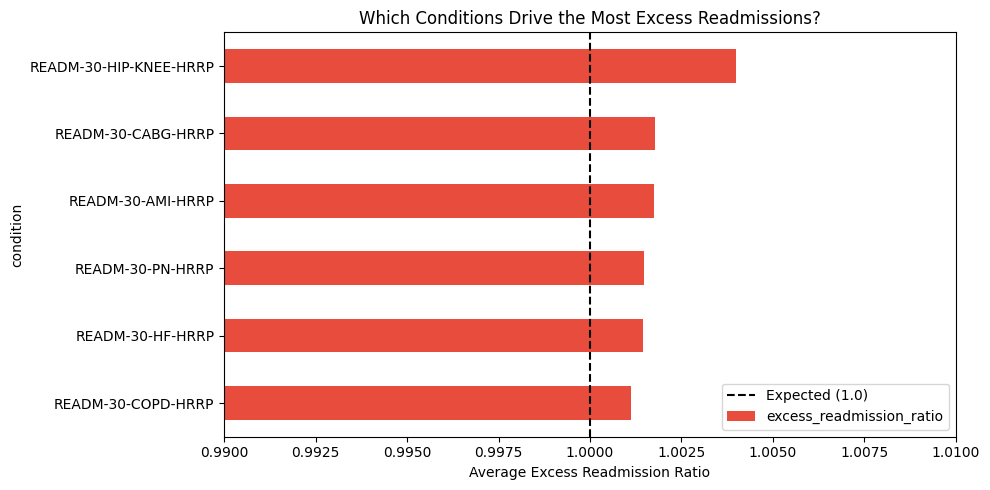

In [30]:
# chart 1: avg ERR by condition
# had to zoom in with xlim bc all values are so close to 1.0 it looked flat otherwise
condition_stats = master[master['excess_readmission_ratio'].notna()].groupby('condition')['excess_readmission_ratio'].mean().sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#e74c3c' if x > 1.0 else '#3498db' for x in condition_stats.values]
condition_stats.plot(kind='barh', ax=ax, color=colors)
ax.axvline(x=1.0, color='black', linestyle='--', label='Expected (1.0)')
ax.set_xlim(0.99, 1.01)
ax.set_xlabel('Average Excess Readmission Ratio')
ax.set_title('Which Conditions Drive the Most Excess Readmissions?')
ax.legend()
plt.tight_layout()
plt.savefig('charts/01_conditions_err.png', dpi=150)
plt.show()

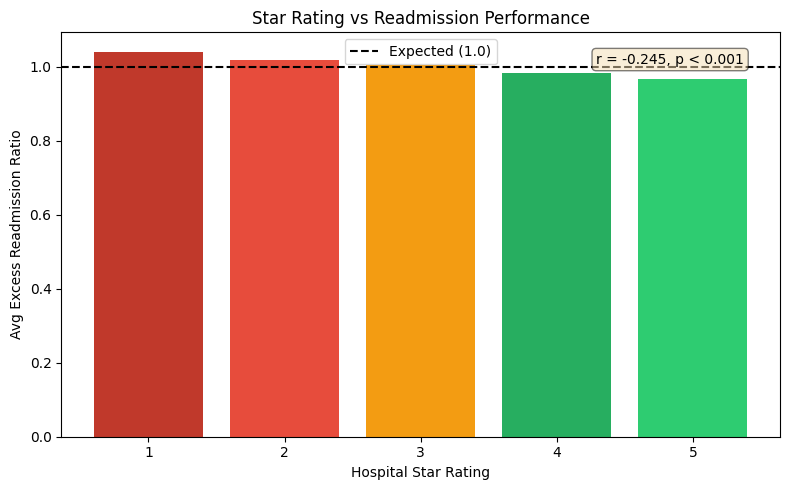

In [31]:
# chart 2: star rating vs ERR
# the gradient is super clear here
star_plot = master[master['overall_rating'].notna() & master['excess_readmission_ratio'].notna()]
star_stats = star_plot.groupby('overall_rating')['excess_readmission_ratio'].mean()

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(star_stats.index, star_stats.values, 
       color=['#c0392b', '#e74c3c', '#f39c12', '#27ae60', '#2ecc71'])
ax.axhline(y=1.0, color='black', linestyle='--', label='Expected (1.0)')
ax.set_xlabel('Hospital Star Rating')
ax.set_ylabel('Avg Excess Readmission Ratio')
ax.set_title('Star Rating vs Readmission Performance')
ax.text(0.95, 0.95, f'r = {corr:.3f}, p < 0.001', transform=ax.transAxes, ha='right', va='top',
        fontsize=10, bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
ax.legend()
plt.tight_layout()
plt.savefig('charts/02_star_vs_err.png', dpi=150)
plt.show()

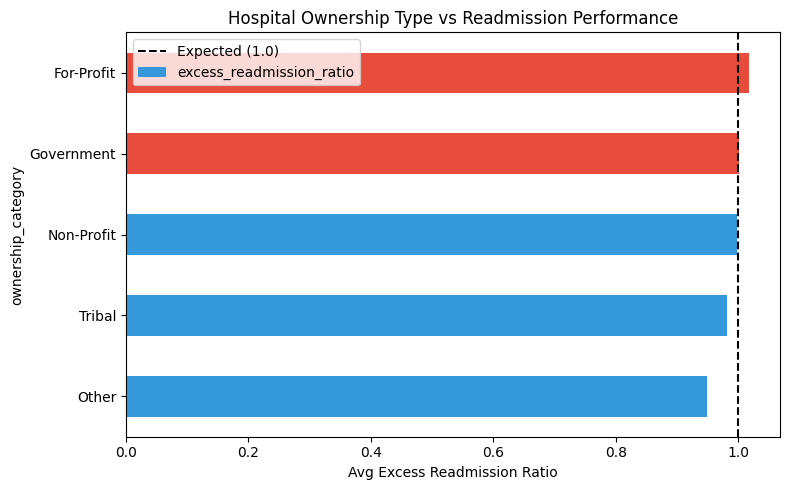

In [32]:
# chart 3: ownership comparison
own_stats = master[master['excess_readmission_ratio'].notna()].groupby('ownership_category')['excess_readmission_ratio'].mean().sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 5))
colors_own = ['#e74c3c' if x > 1.0 else '#3498db' for x in own_stats.values]
own_stats.plot(kind='barh', ax=ax, color=colors_own)
ax.axvline(x=1.0, color='black', linestyle='--', label='Expected (1.0)')
ax.set_xlabel('Avg Excess Readmission Ratio')
ax.set_title('Hospital Ownership Type vs Readmission Performance')
ax.legend()
plt.tight_layout()
plt.savefig('charts/03_ownership_err.png', dpi=150)
plt.show()

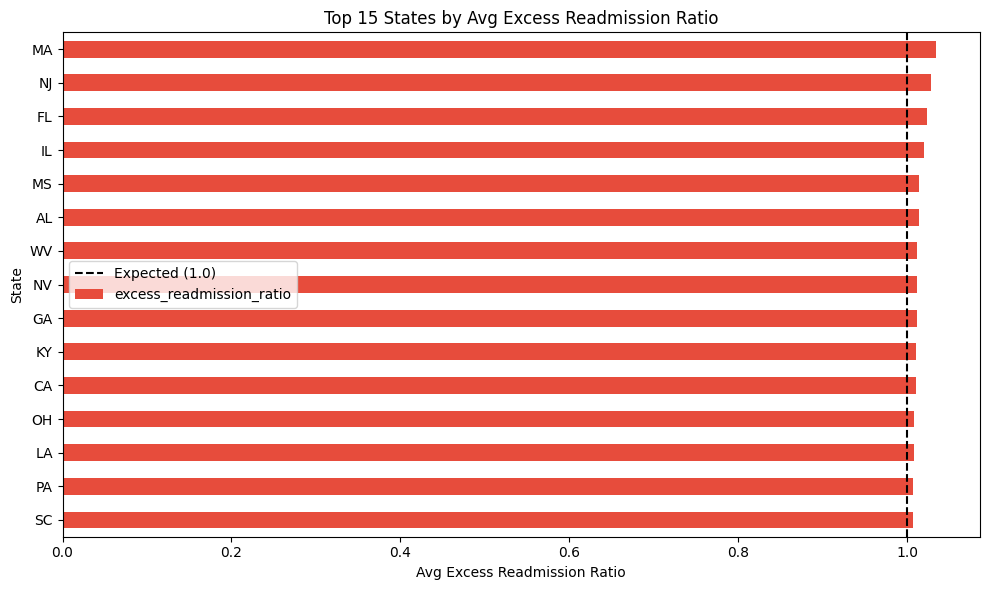

In [33]:
# chart 4: top 15 states by avg ERR
state_stats = master[master['excess_readmission_ratio'].notna()].groupby('State')['excess_readmission_ratio'].mean().sort_values(ascending=False).head(15)

fig, ax = plt.subplots(figsize=(10, 6))
state_stats.sort_values(ascending=True).plot(kind='barh', ax=ax, color='#e74c3c')
ax.axvline(x=1.0, color='black', linestyle='--', label='Expected (1.0)')
ax.set_xlabel('Avg Excess Readmission Ratio')
ax.set_title('Top 15 States by Avg Excess Readmission Ratio')
ax.legend()
plt.tight_layout()
plt.savefig('charts/04_top_states.png', dpi=150)
plt.show()

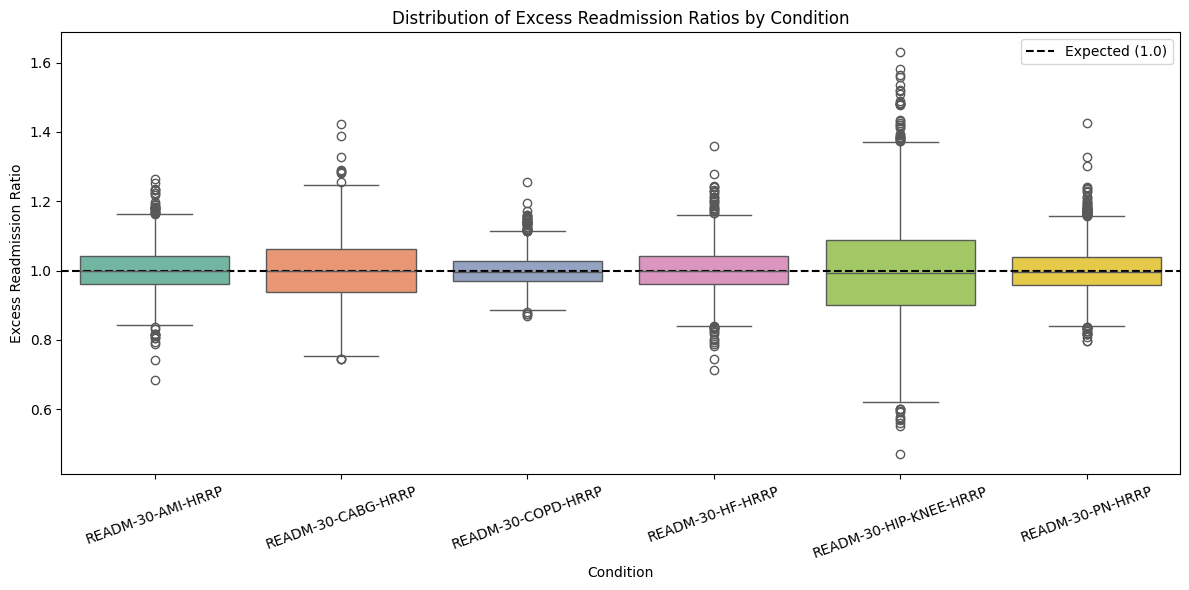

In [34]:
# chart 5: boxplot showing the full distribution by condition
# the bar chart only shows means, this shows outliers and spread
fig, ax = plt.subplots(figsize=(12, 6))
plot_data = master[master['excess_readmission_ratio'].notna()]
sns.boxplot(data=plot_data, x='condition', y='excess_readmission_ratio', palette='Set2', ax=ax)
ax.axhline(y=1.0, color='black', linestyle='--', label='Expected (1.0)')
ax.set_xlabel('Condition')
ax.set_ylabel('Excess Readmission Ratio')
ax.set_title('Distribution of Excess Readmission Ratios by Condition')
ax.legend()
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig('charts/05_err_boxplot.png', dpi=150)
plt.show()

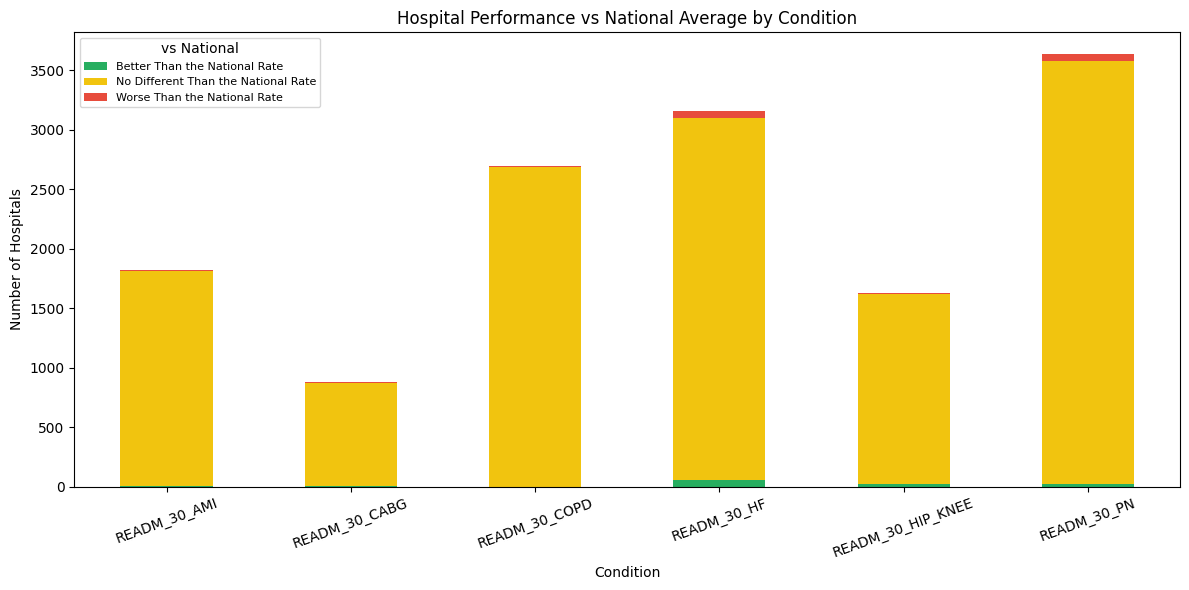

In [35]:
# chart 6: stacked bar — how do hospitals compare to national average?
readmissions = pd.read_sql("""
    SELECT [Measure ID], [Compared to National], COUNT(*) as cnt
    FROM clean_readmissions
    WHERE readmission_rate IS NOT NULL
    GROUP BY [Measure ID], [Compared to National]
""", conn)

fig, ax = plt.subplots(figsize=(12, 6))
pivot = readmissions.pivot(index='Measure ID', columns='Compared to National', values='cnt').fillna(0)
pivot.plot(kind='bar', stacked=True, ax=ax, color=['#27ae60', '#f1c40f', '#e74c3c'])
ax.set_xlabel('Condition')
ax.set_ylabel('Number of Hospitals')
ax.set_title('Hospital Performance vs National Average by Condition')
ax.legend(title='vs National', fontsize=8)
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig('charts/06_vs_national.png', dpi=150)
plt.show()

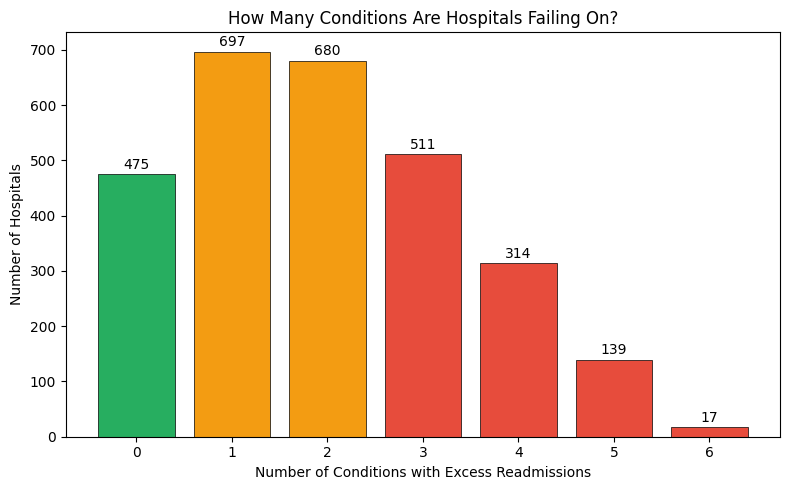

In [36]:
# chart 7: how many conditions are hospitals failing on?
hospital_fails = master[master['excess_readmission_ratio'].notna()].groupby('Facility ID').apply(
    lambda x: (x['excess_readmission_ratio'] > 1.0).sum()
).value_counts().sort_index()

fig, ax = plt.subplots(figsize=(8, 5))
colors_fail = ['#27ae60' if x == 0 else '#f39c12' if x <= 2 else '#e74c3c' for x in hospital_fails.index]
ax.bar(hospital_fails.index, hospital_fails.values, color=colors_fail, edgecolor='black', linewidth=0.5)
ax.set_xlabel('Number of Conditions with Excess Readmissions')
ax.set_ylabel('Number of Hospitals')
ax.set_title('How Many Conditions Are Hospitals Failing On?')
for x, y in zip(hospital_fails.index, hospital_fails.values):
    ax.text(x, y + 10, str(y), ha='center', fontsize=10)
plt.tight_layout()
plt.savefig('charts/07_num_failing_conditions.png', dpi=150)
plt.show()

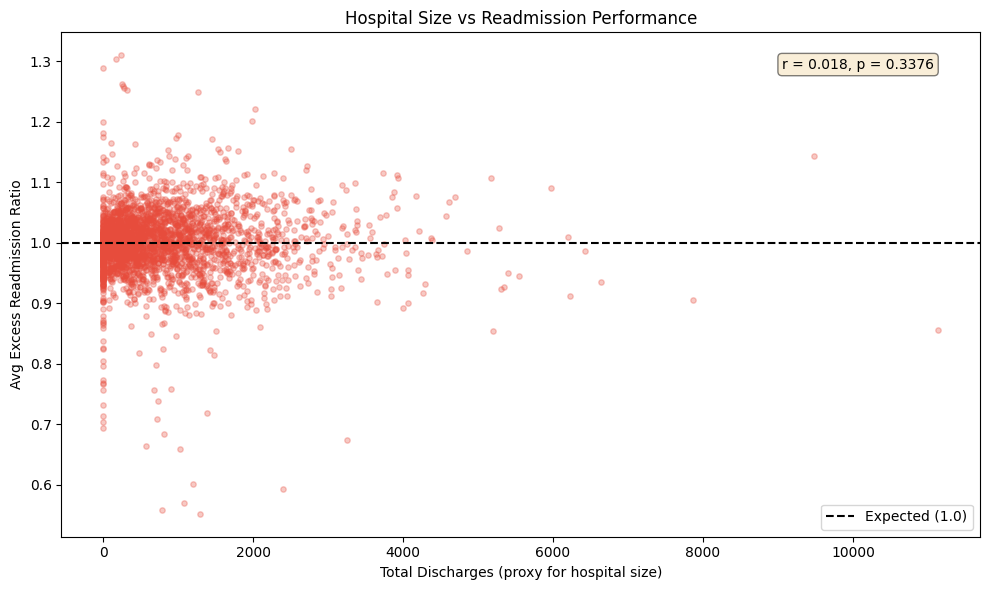

In [37]:
# chart 8: does hospital size matter?
# using total discharges as a rough proxy for how big the hospital is
hosp_size = master[master['excess_readmission_ratio'].notna()].groupby('Facility ID').agg(
    total_discharges=('num_discharges', 'sum'),
    avg_err=('excess_readmission_ratio', 'mean')
).dropna()

fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(hosp_size['total_discharges'], hosp_size['avg_err'], alpha=0.3, s=15, c='#e74c3c')
ax.axhline(y=1.0, color='black', linestyle='--', label='Expected (1.0)')
ax.set_xlabel('Total Discharges (proxy for hospital size)')
ax.set_ylabel('Avg Excess Readmission Ratio')
ax.set_title('Hospital Size vs Readmission Performance')
size_corr, size_p = stats.pearsonr(hosp_size['total_discharges'], hosp_size['avg_err'])
ax.text(0.95, 0.95, f'r = {size_corr:.3f}, p = {size_p:.4f}', transform=ax.transAxes, ha='right', va='top',
        fontsize=10, bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
ax.legend()
plt.tight_layout()
plt.savefig('charts/08_size_vs_err.png', dpi=150)
plt.show()

---
## 7. Save SQL Queries & Export Data

In [38]:
os.makedirs('sql', exist_ok=True)

with open('sql/01_exploration.sql', 'w') as f:
    f.write("""-- data exploration queries
-- checking whats in each table and finding messy values

SELECT [Measure ID], COUNT(*) as cnt 
FROM raw_unplanned_visits 
GROUP BY [Measure ID];

SELECT [Excess Readmission Ratio], COUNT(*) as cnt
FROM raw_hrrp
WHERE [Excess Readmission Ratio] IS NULL 
GROUP BY [Excess Readmission Ratio];

SELECT Score, COUNT(*) as cnt
FROM raw_unplanned_visits
WHERE Score = 'Not Available' OR Score IS NULL
GROUP BY Score;

SELECT 'hospital_info' as tbl, COUNT(DISTINCT [Facility ID]) as cnt FROM raw_hospital_info
UNION ALL
SELECT 'hrrp', COUNT(DISTINCT [Facility ID]) FROM raw_hrrp
UNION ALL
SELECT 'unplanned_visits', COUNT(DISTINCT [Facility ID]) FROM raw_unplanned_visits;

SELECT [Measure ID],
       COUNT(*) as total,
       SUM(CASE WHEN Score != 'Not Available' AND Score IS NOT NULL THEN 1 ELSE 0 END) as has_data,
       SUM(CASE WHEN Score = 'Not Available' OR Score IS NULL THEN 1 ELSE 0 END) as missing
FROM raw_unplanned_visits
WHERE [Measure ID] LIKE 'READM_30%'
GROUP BY [Measure ID];
""")
print('saved 01_exploration.sql')

saved 01_exploration.sql


In [39]:
with open('sql/02_clean_data.sql', 'w') as f:
    f.write("""-- cleaning CMS data
-- converting Not Available to NULL, casting types, filtering measures

DROP TABLE IF EXISTS clean_hrrp;
CREATE TABLE clean_hrrp AS
SELECT 
    [Facility ID], [Facility Name], State, [Measure Name],
    CASE 
        WHEN [Excess Readmission Ratio] IS NULL THEN NULL
        WHEN [Excess Readmission Ratio] = '' THEN NULL
        ELSE CAST([Excess Readmission Ratio] AS REAL)
    END as excess_readmission_ratio,
    CASE
        WHEN [Number of Discharges] IS NULL THEN NULL
        WHEN [Number of Discharges] = '' THEN NULL
        ELSE CAST([Number of Discharges] AS INTEGER)
    END as num_discharges,
    CASE
        WHEN [Number of Readmissions] IS NULL THEN NULL
        ELSE CAST([Number of Readmissions] AS INTEGER)
    END as num_readmissions
FROM raw_hrrp;

DROP TABLE IF EXISTS clean_hospital_info;
CREATE TABLE clean_hospital_info AS
SELECT 
    [Facility ID], [Facility Name], [City/Town] as city, State,
    [ZIP Code], [County/Parish] as county, [Hospital Type], [Hospital Ownership],
    [Emergency Services],
    CASE 
        WHEN [Hospital overall rating] = 'Not Available' THEN NULL
        ELSE CAST([Hospital overall rating] AS INTEGER)
    END as overall_rating,
    CASE
        WHEN [Hospital Ownership] LIKE '%non-profit%' THEN 'Non-Profit'
        WHEN [Hospital Ownership] LIKE '%Proprietary%' THEN 'For-Profit'
        WHEN [Hospital Ownership] LIKE '%Government%' THEN 'Government'
        WHEN [Hospital Ownership] LIKE '%Tribal%' THEN 'Tribal'
        ELSE 'Other'
    END as ownership_category
FROM raw_hospital_info;

DROP TABLE IF EXISTS clean_readmissions;
CREATE TABLE clean_readmissions AS
SELECT 
    [Facility ID], [Facility Name], State, [Measure ID], [Measure Name],
    CASE WHEN Score = 'Not Available' THEN NULL ELSE CAST(Score AS REAL) END as readmission_rate,
    CASE WHEN Denominator = 'Not Available' THEN NULL ELSE CAST(Denominator AS INTEGER) END as num_discharges,
    [Compared to National]
FROM raw_unplanned_visits
WHERE [Measure ID] LIKE 'READM_30%';
""")
print('saved 02_clean_data.sql')

saved 02_clean_data.sql


In [40]:
with open('sql/03_join_and_analysis.sql', 'w') as f:
    f.write("""-- join tables and run analysis queries

DROP TABLE IF EXISTS master_hospital;
CREATE TABLE master_hospital AS
SELECT 
    h.[Facility ID], h.[Facility Name], h.city, h.State, h.county,
    h.[Hospital Type], h.[Hospital Ownership], h.ownership_category,
    h.overall_rating, h.[Emergency Services],
    p.[Measure Name] as condition,
    p.excess_readmission_ratio, p.num_discharges, p.num_readmissions
FROM clean_hospital_info h
INNER JOIN clean_hrrp p ON h.[Facility ID] = p.[Facility ID];

-- conditions analysis
SELECT condition, COUNT(*) as n,
       ROUND(AVG(excess_readmission_ratio), 4) as avg_err,
       SUM(CASE WHEN excess_readmission_ratio > 1.0 THEN 1 ELSE 0 END) as num_above,
       ROUND(100.0 * SUM(CASE WHEN excess_readmission_ratio > 1.0 THEN 1 ELSE 0 END) / COUNT(*), 1) as pct_above
FROM master_hospital WHERE excess_readmission_ratio IS NOT NULL
GROUP BY condition ORDER BY avg_err DESC;

-- ownership comparison
SELECT ownership_category, COUNT(DISTINCT [Facility ID]) as n,
       ROUND(AVG(excess_readmission_ratio), 4) as avg_err
FROM master_hospital WHERE excess_readmission_ratio IS NOT NULL
GROUP BY ownership_category ORDER BY avg_err DESC;

-- star rating vs ERR
SELECT overall_rating, COUNT(DISTINCT [Facility ID]) as n,
       ROUND(AVG(excess_readmission_ratio), 4) as avg_err
FROM master_hospital
WHERE overall_rating IS NOT NULL AND excess_readmission_ratio IS NOT NULL
GROUP BY overall_rating ORDER BY overall_rating;

-- worst offenders
SELECT [Facility ID], [Facility Name], State, ownership_category, overall_rating,
       COUNT(*) as conditions_measured,
       SUM(CASE WHEN excess_readmission_ratio > 1.0 THEN 1 ELSE 0 END) as conditions_failing,
       ROUND(AVG(excess_readmission_ratio), 4) as avg_err
FROM master_hospital WHERE excess_readmission_ratio IS NOT NULL
GROUP BY [Facility ID], [Facility Name], State, ownership_category, overall_rating
HAVING conditions_failing >= 4
ORDER BY conditions_failing DESC, avg_err DESC;
""")
print('saved 03_join_and_analysis.sql')

saved 03_join_and_analysis.sql


In [41]:
# export for tableau
os.makedirs('data/processed', exist_ok=True)
master.to_csv('data/processed/master_hospital.csv', index=False)

readm = pd.read_sql("SELECT * FROM clean_readmissions", conn)
readm.to_csv('data/processed/readmission_details.csv', index=False)

print(f'exported master_hospital.csv ({len(master)} rows)')
print(f'exported readmission_details.csv ({len(readm)} rows)')

exported master_hospital.csv (18330 rows)
exported readmission_details.csv (28734 rows)


---
## Key Findings

1. **For-profit hospitals have significantly higher excess readmission ratios** (avg ERR 1.0174, n=551) compared to non-profits (0.9984, n=1831). T-test confirms this difference is statistically significant, not just noise.

2. **Star rating strongly correlates with readmission performance.** 1-star hospitals average an ERR of ~1.04 while 5-star hospitals are at ~0.97. Spearman correlation is negative and highly significant (p < 0.001) across 10,000+ observations.

3. **Hip/Knee replacement has the highest avg ERR** (1.0040) despite being an elective procedure. This is counterintuitive — planned surgeries should be easier to manage. Could be worth investigating whether this is driven by patient demographics or discharge practices.

4. **~48% of hospitals exceed expected readmission rates** for any given condition. Some hospitals are failing on all 6 measured conditions simultaneously.

5. **Hospital size (measured by total discharges) shows weak correlation with ERR**, suggesting both small and large hospitals can have readmission problems.

### What I'd improve with more time
- Run a logistic regression to see which factors (ownership, size, state, star rating) best predict excess readmissions
- Add year-over-year trend analysis since CMS publishes this data annually — are the same hospitals getting penalized repeatedly?

In [42]:
conn.close()
print('done!')

done!
